In [1]:
!pip uninstall transformers -y
!pip install transformers==4.38.2

Found existing installation: transformers 4.38.2
Uninstalling transformers-4.38.2:
  Successfully uninstalled transformers-4.38.2
  Using cached transformers-4.38.2-py3-none-any.whl.metadata (130 kB)
Using cached transformers-4.38.2-py3-none-any.whl (8.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
fake = pd.read_csv("/content/drive/MyDrive/Fake.csv")
real = pd.read_csv("/content/drive/MyDrive/True.csv")

fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real]).reset_index(drop=True)

In [4]:
df.shape

(44898, 5)

In [5]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


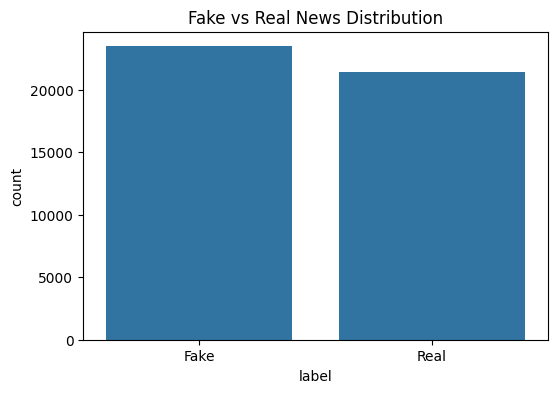

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Distribution")
plt.xticks([0,1], ["Fake", "Real"])
plt.show()

In [8]:
print("\nClass distribution:\n")
print(df["label"].value_counts())
print("\nClass distribution (%):\n")
print(df["label"].value_counts(normalize=True))


Class distribution:

label
0    23481
1    21417
Name: count, dtype: int64

Class distribution (%):

label
0    0.522985
1    0.477015
Name: proportion, dtype: float64


In [9]:
df["text"] = df["text"].astype(str)
df["text_length"] = df["text"].apply(len)

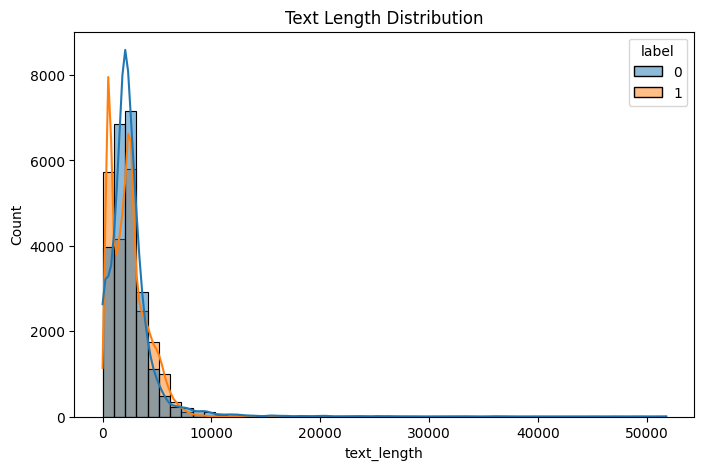

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="text_length", hue="label", bins=50, kde=True)
plt.title("Text Length Distribution")
plt.show()

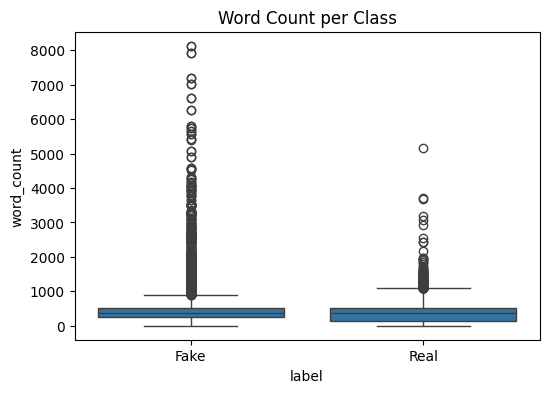

In [11]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="word_count", data=df)
plt.xticks([0,1], ["Fake", "Real"])
plt.title("Word Count per Class")
plt.show()

In [12]:
print("\nAverage text length:\n")
print(df.groupby("label")["text_length"].mean())


Average text length:

label
0    2547.396235
1    2383.278517
Name: text_length, dtype: float64


In [13]:
print("\nAverage word count:\n")
print(df.groupby("label")["word_count"].mean())


Average word count:

label
0    423.197905
1    385.640099
Name: word_count, dtype: float64


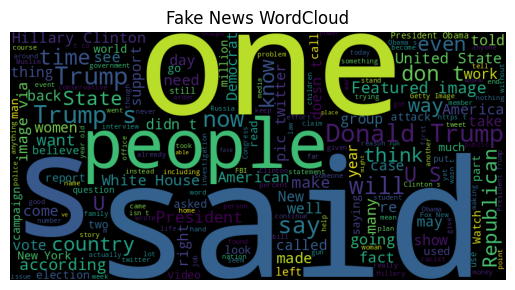

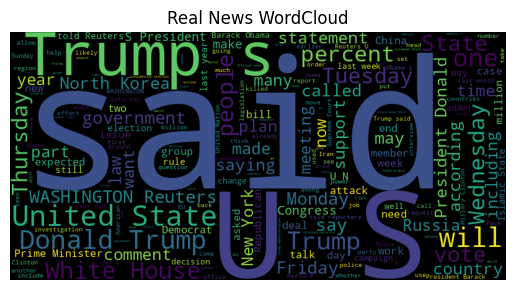

In [14]:
from wordcloud import WordCloud

fake_text = " ".join(df[df["label"]==0]["text"])
real_text = " ".join(df[df["label"]==1]["text"])

wc_fake = WordCloud(width=800, height=400).generate(fake_text)
wc_real = WordCloud(width=800, height=400).generate(real_text)

plt.imshow(wc_fake)
plt.title("Fake News WordCloud")
plt.axis("off")
plt.show()

plt.imshow(wc_real)
plt.title("Real News WordCloud")
plt.axis("off")
plt.show()

In [15]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove links
    text = re.sub(r"[^a-z\s]", "", text)       # keep only letters
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

df["text"] = df["text"].apply(clean_text)

In [16]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

In [17]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [18]:
import torch

class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)
test_dataset = NewsDataset(test_encodings, test_labels)

In [19]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    overwrite_output_dir=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [26]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir="./logs"
)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, train_labels)

LogisticRegression(max_iter=200)

In [31]:
from sklearn.metrics import classification_report

val_pred = model.predict(X_val)

print("VALIDATION RESULTS:\n")
print(classification_report(val_labels, val_pred))

VALIDATION RESULTS:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2348
           1       0.99      0.99      0.99      2142

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490



In [32]:
test_pred = model.predict(X_test)

print("TEST RESULTS:\n")
print(classification_report(test_labels, test_pred))

TEST RESULTS:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2385
           1       0.99      0.99      0.99      2105

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490



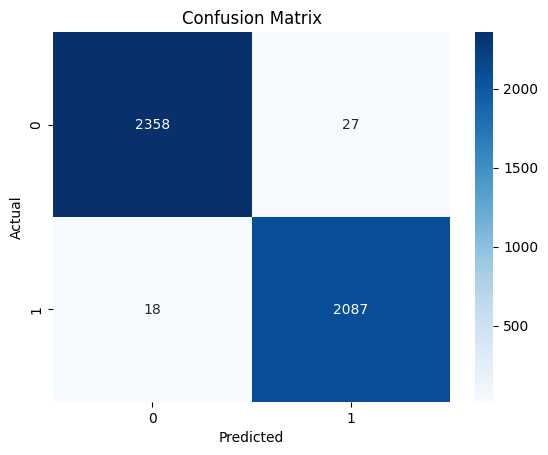

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()